<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report


In [97]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


# Load the dataset
import pandas as pd

df = pd.read_csv('/content/amazon_alexa.tsv', sep='\t')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


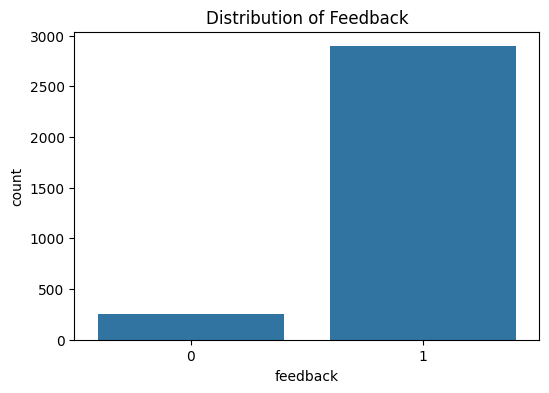

In [98]:
# TODO: Visualize the distribution of feedback
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='feedback')
plt.title("Distribution of Feedback")
plt.show()


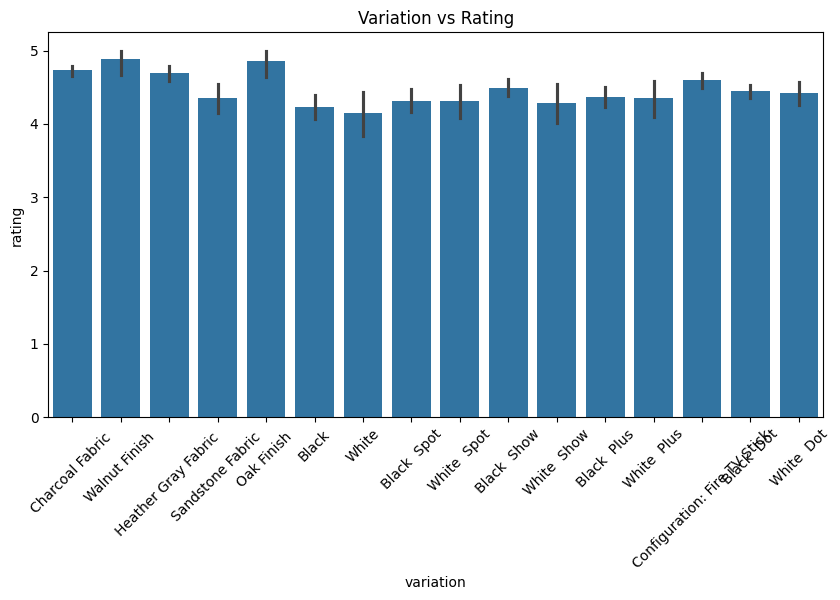

In [99]:
# TODO: Visualize the relationship between variations and ratings
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='variation', y='rating')
plt.title("Variation vs Rating")
plt.xticks(rotation=45)
plt.show()


In [100]:
# Hint: Use the drop() method to remove 'date' and 'rating' columns
df = df.drop(['date', 'rating'], axis=1)

In [101]:
# TODO: Perform one-hot encoding on the 'variation' column
variation_dummies = pd.get_dummies(df['variation'], prefix='var')
df = pd.concat([df, variation_dummies], axis=1)
df = df.drop('variation', axis=1)


In [102]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column

# Replace NaN reviews with empty strings
df['verified_reviews'] = df['verified_reviews'].fillna("")

vectorizer = CountVectorizer(stop_words='english')
review_tokens = vectorizer.fit_transform(df['verified_reviews'])

review_df = pd.DataFrame(review_tokens.toarray(), columns=vectorizer.get_feature_names_out())


In [103]:
# TODO: Combine tokenized reviews with the main dataframe
df_combined = pd.concat([df.drop('verified_reviews', axis=1), review_df], axis=1)


In [104]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
X = df_combined.drop('feedback', axis=1)
# Ensure y is a single Series, not a DataFrame with multiple 'feedback' columns
y = df_combined['feedback'].iloc[:, 0] if isinstance(df_combined['feedback'], pd.DataFrame) else df_combined['feedback']

In [105]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [106]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

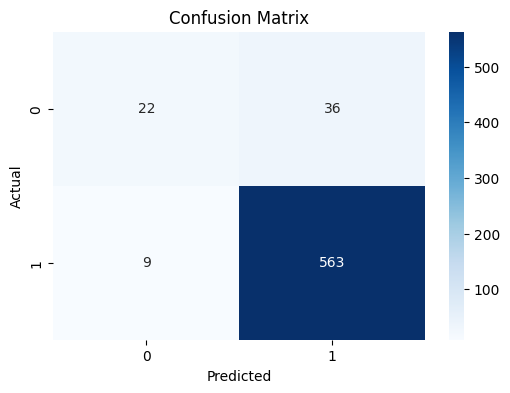

In [107]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metricsmodel = RandomForestClassifier(n_estimators=200, random_state=42)
y_pred = model.predict(X_test)

# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [108]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.38      0.49        58
           1       0.94      0.98      0.96       572

    accuracy                           0.93       630
   macro avg       0.82      0.68      0.73       630
weighted avg       0.92      0.93      0.92       630



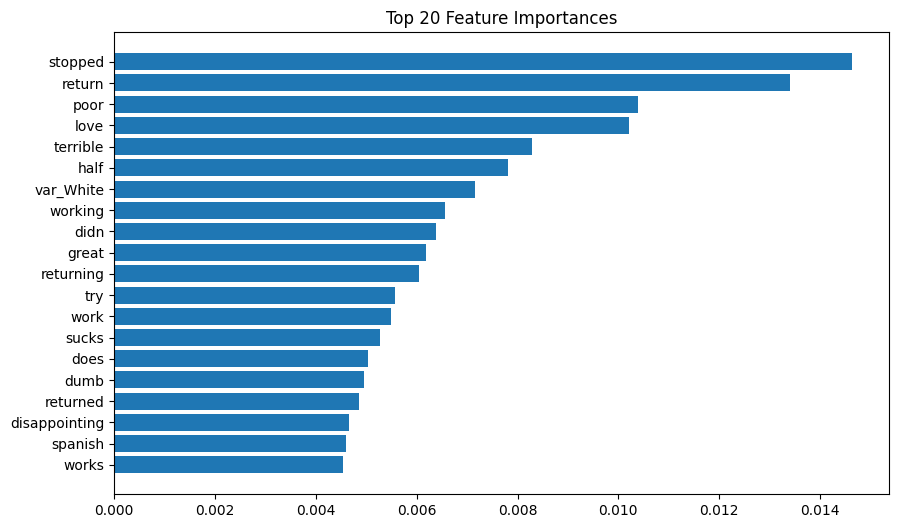

In [109]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 20 Feature Importances")
plt.show()


In [110]:
def predict_sentiment(review_text):
    # Tokenize new review
    review_vec = vectorizer.transform([review_text])
    review_df_new = pd.DataFrame(review_vec.toarray(), columns=vectorizer.get_feature_names_out())

    # Align columns with training data
    missing_cols = set(X.columns) - set(review_df_new.columns)
    for col in missing_cols:
        review_df_new[col] = 0
    review_df_new = review_df_new[X.columns]

    # Predict
    prediction = model.predict(review_df_new)[0]
    return "Positive" if prediction == 1 else "Negative"


In [111]:
# Example usage of your prediction function:
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print("Predicted sentiment:", predicted_sentiment)

Predicted sentiment: Positive
